In [1]:
## Load necessary library files ##

import sys
sys.path.append('..')
from source.utils import get_sequence, DatasetConverter
from source.model.model import Model

## Load standard files ##
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from torch import from_numpy as tnsr
from sklearn.metrics.pairwise import rbf_kernel
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch.nn.functional as F
from tqdm import tqdm
import pickle 

In [30]:
# =========================================================
# MMD utilities
# =========================================================
def _to_2d_tensor(x, device="cpu"):
    """
    Accepts either:
      - list of tensors, each shape (...,)
      - tensor of shape (n, d) or compatible
    Returns:
      tensor of shape (n, d)
    """
    if isinstance(x, list):
        x = torch.stack([t.detach().clone().flatten() for t in x], dim=0)
    elif torch.is_tensor(x):
        if x.ndim == 1:
            x = x.unsqueeze(0)
        else:
            x = x.reshape(x.shape[0], -1)
    else:
        raise TypeError("Input must be a list of tensors or a tensor.")
    return x.to(device).float()


def pairwise_sq_dists(x, y):
    """
    x: (n, d)
    y: (m, d)
    returns: (n, m) matrix of squared Euclidean distances
    """
    x_norm = (x ** 2).sum(dim=1, keepdim=True)           # (n, 1)
    y_norm = (y ** 2).sum(dim=1, keepdim=True).T         # (1, m)
    d2 = x_norm + y_norm - 2.0 * (x @ y.T)
    return torch.clamp(d2, min=0.0)


def median_heuristic_sigma(x, y, eps=1e-8):
    """
    Median heuristic for RBF bandwidth.
    Uses all pairwise squared distances from concatenated samples.
    """
    z = torch.cat([x, y], dim=0)
    d2 = pairwise_sq_dists(z, z)

    mask = ~torch.eye(d2.shape[0], dtype=torch.bool, device=d2.device)
    vals = d2[mask]

    vals = vals[vals > 0]
    if vals.numel() == 0:
        return torch.tensor(1.0, device=z.device)

    sigma = torch.sqrt(torch.median(vals) / 2.0 + eps)
    return sigma


def mmd_rbf(x, y, sigma=None, unbiased=True, device="cpu", return_sigma=False):
    """
    Computes MMD^2 with an RBF kernel.

    x, y can be:
      - list of tensors
      - tensors of shape (n, d)

    Returns:
      scalar float by default
      if return_sigma=True, returns (mmd2_float, sigma_float)
    """
    x = _to_2d_tensor(x, device=device)
    y = _to_2d_tensor(y, device=device)

    if sigma is None:
        sigma = median_heuristic_sigma(x, y)

    dxx = pairwise_sq_dists(x, x)
    dyy = pairwise_sq_dists(y, y)
    dxy = pairwise_sq_dists(x, y)

    kxx = torch.exp(-dxx / (2.0 * sigma * sigma))
    kyy = torch.exp(-dyy / (2.0 * sigma * sigma))
    kxy = torch.exp(-dxy / (2.0 * sigma * sigma))

    n = x.shape[0]
    m = y.shape[0]

    if unbiased:
        if n < 2 or m < 2:
            mmd2 = torch.tensor(0.0, device=device)
        else:
            sum_kxx = (kxx.sum() - torch.diagonal(kxx).sum()) / (n * (n - 1))
            sum_kyy = (kyy.sum() - torch.diagonal(kyy).sum()) / (m * (m - 1))
            sum_kxy = kxy.mean()
            mmd2 = sum_kxx + sum_kyy - 2.0 * sum_kxy
    else:
        mmd2 = kxx.mean() + kyy.mean() - 2.0 * kxy.mean()

    mmd2 = torch.clamp(mmd2, min=0.0)

    if return_sigma:
        return float(mmd2.item()), float(sigma.item())
    return float(mmd2.item())



In [31]:
device = "cpu" 

print("Using device:", device)

Using device: cpu


In [35]:
total_samples, n_community, n_members, context_depth = 1000000, 2, 3, 2
total_layers, short_term_memory = 2, 4

vocab_size = n_community*n_members + 1

In [ ]:
# =========================================================
# Experiment
# =========================================================
reps = 10

res = []
repititions = []
samples_seen = []

replay_dists = []
baseline_dists = []
noise_dists = []

sigma_replay_list = []
sigma_baseline_list = []
sigma_noise_list = []

for rep in tqdm(range(reps)):
    model = Model(
        total_layers=total_layers,

        # ---- Layer sizes ----
        vocab_size=vocab_size,
        hidden_sizes=[100, 100],
        embedding_dim=30,

        # ---- Learning rates per layer ----
        lr_layers=1e-4,

        # ---- Optimizer type ----
        optimizer_class=torch.optim.Adam,
        optimizer_kwargs={
            "weight_decay": 1e-12
        },

        # ---- Sleep hyperparameters ----
        short_term_memory=short_term_memory,
        context_tag_buffer_size=10,

        # ---- Misc ----
        recon_threshold=1e-3,
        device=device
    )

    data = get_sequence(
        total_samples,
        n_community,
        n_members,
        context_depth=context_depth,
        train_percent=1.0
    )

    dataset = DatasetConverter(data, short_term_memory=short_term_memory)
    loader = DataLoader(dataset, batch_size=1, shuffle=False)

    ii = 0
    h_ = None
    correct_ring = np.zeros(1000)

    context_tags = []
    wake_exp = []

    for x, y in loader:
        x = x.to(device).long()
        y = y.to(device).long()

        logits, loss, recon_loss, h_, context = model.wake_step(x, y, h_, return_context=True)

        with torch.no_grad():
            ii += 1

            # store detached copies
            if ii%20==0:
                stored_h0 = model.h_states[0].detach().clone().cpu()
                stored_context = context.detach().clone().cpu() if torch.is_tensor(context) else context
                context_tags.append((stored_h0, stored_context))


            stored_wake = model.h_states[0].detach().clone().cpu()
            wake_exp.append(stored_wake)

            pred_tok = logits.argmax(dim=-1)
            correct_ring[ii % 1000] = (pred_tok[0] == y[0, 0]).item()

            if ii % 1000 == 0:
                # ---------- wake ----------
                wake_eval = [w.flatten() for w in wake_exp]

                # ---------- sleep replay ----------
                sleep_exp = []
                for h0, ctx in context_tags:
                    h_states = h0.unsqueeze(0).to(device)

                    if torch.is_tensor(ctx):
                        ctx_in = ctx.to(device)
                    else:
                        ctx_in = ctx

                    for jj in range(20):
                        h_states, _ = model._teacher_step_layer0(
                            h_states,
                            context=ctx_in
                        )
                        sleep_exp.append(h_states[0][0].detach().cpu().flatten())

                # ---------- baseline: random split of wake ----------
                perm = np.random.permutation(len(wake_eval))
                mid = len(perm) // 2
                wake_a = [wake_eval[i] for i in perm[:mid]]
                wake_b = [wake_eval[i] for i in perm[mid:]]

                # ---------- noise reference ----------
                wake_tensor = torch.stack(wake_eval, dim=0)  # (n, d)

                # noise matched to wake mean/std for a fairer reference
                wake_mean = wake_tensor.mean(dim=0, keepdim=True)
                wake_std = wake_tensor.std(dim=0, keepdim=True) + 1e-8
                noise_tensor = torch.randn_like(wake_tensor) * wake_std + wake_mean
                noise_exp = [noise_tensor[i] for i in range(noise_tensor.shape[0])]

                # ---------- MMDs ----------
                replay_mmd, sigma_replay = mmd_rbf(
                    wake_eval, sleep_exp, sigma=None, unbiased=True, device="cpu", return_sigma=True
                )
                baseline_mmd, sigma_baseline = mmd_rbf(
                    wake_a, wake_b, sigma=None, unbiased=True, device="cpu", return_sigma=True
                )
                noise_mmd, sigma_noise = mmd_rbf(
                    wake_eval, noise_exp, sigma=None, unbiased=True, device="cpu", return_sigma=True
                )

                acc = np.sum(correct_ring) / 1000.0

                # print(
                #     f"replay: {replay_mmd:.6f} | "
                #     f"baseline: {baseline_mmd:.6f} | "
                #     f"noise: {noise_mmd:.6f} | "
                #     f"acc: {acc:.3f} | "
                #     f"sigma_r: {sigma_replay:.6f} | "
                #     f"sigma_b: {sigma_baseline:.6f} | "
                #     f"sigma_n: {sigma_noise:.6f}"
                # )

                replay_dists.append(replay_mmd)
                baseline_dists.append(baseline_mmd)
                noise_dists.append(noise_mmd)

                sigma_replay_list.append(sigma_replay)
                sigma_baseline_list.append(sigma_baseline)
                sigma_noise_list.append(sigma_noise)

                res.append(acc)
                samples_seen.append(ii)
                repititions.append(rep)

                wake_exp = []
                context_tags = []

        if ii % 20000 == 0:
            model.sleep(total_steps=16)

# =========================================================
# Save results
# =========================================================
df = pd.DataFrame()
df["reps"] = repititions
df["samples seen"] = samples_seen
df["Accuracy"] = res
df["Replay MMD^2"] = replay_dists
df["Wake Split MMD^2"] = baseline_dists
df["Noise MMD^2"] = noise_dists
df["Replay sigma"] = sigma_replay_list
df["Baseline sigma"] = sigma_baseline_list
df["Noise sigma"] = sigma_noise_list

with open('../pickle_files/generation_quality.pickle', 'wb') as f:
    pickle.dump(df, f)

100%|██████████| 10/10 [4:48:03<00:00, 1728.34s/it] 


In [40]:
df.head()

,reps,samples seen,Accuracy,Replay MMD^2,Wake Split MMD^2,Noise MMD^2,Replay sigma,Baseline sigma,Noise sigma
0,0,1000,0.225,0.013761,0.000000,0.022783,4.622933,4.348078,4.419400
1,0,2000,0.273,0.003438,0.000000,0.019664,5.492666,5.521673,5.480013
2,0,3000,0.393,0.001123,0.000000,0.017574,5.768747,5.835193,5.797183
3,0,4000,0.479,0.001567,0.000000,0.017121,5.862854,5.921297,5.882921
4,0,5000,0.534,0.000607,0.000653,0.016821,5.921989,5.959579,5.935504


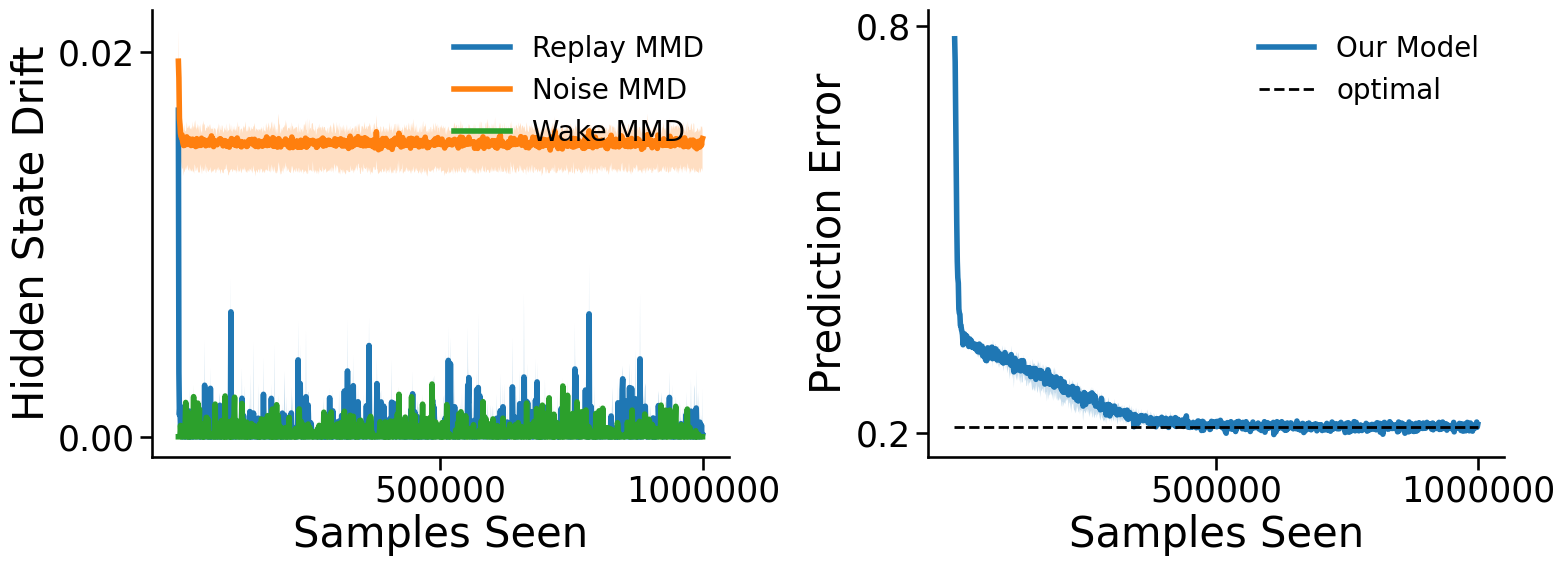

In [2]:
sns.set_context("talk")

# ---------- Load ----------
with open('../pickle_files/generation_quality.pickle', 'rb') as f:
    df = pickle.load(f)


# ---------- Ensure samples_seen exists ----------
def ensure_samples_seen(df, checkpoint_every=1000):
    df = df.copy()
    if "samples_seen" in df.columns:
        return df
    df["_idx"] = df.groupby("reps").cumcount() + 1
    df["samples_seen"] = df["_idx"] * checkpoint_every
    return df.drop(columns="_idx")

df_not = ensure_samples_seen(df)

# ---------- Limit to 200k samples ----------
df_not = df_not[df_not["samples_seen"] <= 1000000]

# ---------- Compute median + IQR ----------
def compute_stats(df, criterion="Replay MMD^2"):
    g = df.groupby("samples_seen")[criterion]
    x = g.median().index.values
    median = g.median().values
    q25 = g.quantile(0.25).values
    q75 = g.quantile(0.75).values
    return x, median, q25, q75

x_not, m_not, q25_not, q75_not = compute_stats(df_not)
x_noise, m_noise, q25_noise, q75_noise = compute_stats(df_not, 'Noise MMD^2')
x_wake, m_wake, q25_wake, q75_wake = compute_stats(df_not, 'Wake Split MMD^2')
x_acc, acc, q25_acc, q75_acc = compute_stats(df_not, 'Accuracy')

# ---------- Plot ----------
fig, ax = plt.subplots(1, 2, figsize=(16,6))


ax[1].plot(x_acc, 1-acc, linewidth=4, label='Our Model')
ax[1].fill_between(x_acc, 1-q25_acc, 1-q75_acc, alpha=0.25)

ax[0].plot(x_not, m_not, linewidth=4, label="Replay MMD")
ax[0].fill_between(x_not, q25_not, q75_not, alpha=0.25)

ax[0].plot(x_noise, m_noise, linewidth=4, label="Noise MMD")
ax[0].fill_between(x_noise, q25_noise, q75_noise, alpha=0.25)

ax[0].plot(x_wake, m_wake, linewidth=4, label="Wake MMD")
ax[0].fill_between(x_wake, q25_wake, q75_wake, alpha=0.25)

ax[0].set_ylabel("Hidden State Drift", fontsize=30)
ax[1].set_ylabel("Prediction Error", fontsize=30)

for ii in range(2):
    ax[ii].spines["right"].set_visible(False)
    ax[ii].spines["top"].set_visible(False)
    ax[ii].set_xticks([500000, 1000000])
    ax[ii].set_xlabel("Samples Seen", fontsize=30)
    ax[ii].tick_params(labelsize=25)
    ax[ii].ticklabel_format(style='plain', axis='x')

ax[0].set_yticks([0, 0.02])
ax[1].set_yticks([0, 0.2, 0.8])
ax[1].hlines(0.2083, 1, 1000000, linestyle='--', color='black', linewidth=2, label='optimal')

ax[0].legend(loc="upper right", frameon=False, fontsize=20)
ax[1].legend(loc="upper right", frameon=False, fontsize=20)
# ax[0].legend(
#     bbox_to_anchor=(.5, -.5),
#     loc="lower center",
#     ncol=6,
#     fontsize=20,
#     frameon=False
# )

plt.tight_layout()

plt.savefig('../plots/generation_quality.pdf', bbox_inches='tight')
plt.show()